# MAP - skala
Datacamp 2024 - Tristan Waddington

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib import reload

import os
import sklearn
import rampwf

import problem

pd.set_option("display.max_columns", None)
print("sklearn", sklearn.__version__)
print("ramp", rampwf.__version__)

sklearn 1.6.0
ramp 0.7.0


## 1. Data exploration

In [3]:
os.environ["RAMP_TEST_MODE"] = "7"
X_df, y = problem.get_train_data()

In [3]:
X_df.shape

(2100, 12)

In [4]:
X_df.head()

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN


In [5]:
X_df["domain"].value_counts()

domain
m    1100
v    1000
Name: count, dtype: int64

### Skala preparation

In [6]:
X_df["sample_domain"] = X_df["domain"].map({"v": 1, "m": -1})
X_df

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk,sample_domain
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN,1
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN,1
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN,1
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN,1
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2785793562708102, 0.28412874583795783, 0.25...","[0.19241192411924118, 0.1603432700993677, 0.13...",val,-1
2096,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2987085906793936, 0.3161145423919146, 0.212...","[0.11162361623616242, 0.11531365313653143, 0.1...",val,-1
2097,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.20290697674418606, 0.1430232558139535, 0.10...","[0.04311482622085346, 0.04311482622085346, 0.0...",val,-1
2098,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.19429778247096094, 0.18373812038014786, 0.1...","[0.20263870094722602, 0.18775372124492556, 0.1...",val,-1


In [7]:
# Selected numerical columns for the first regressor
num_cols = ["age", "height", "weight", "bmi"]


## 2. Regressor

In [8]:
X_df


,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk,sample_domain
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN,1
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN,1
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN,1
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN,1
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2785793562708102, 0.28412874583795783, 0.25...","[0.19241192411924118, 0.1603432700993677, 0.13...",val,-1
2096,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2987085906793936, 0.3161145423919146, 0.212...","[0.11162361623616242, 0.11531365313653143, 0.1...",val,-1
2097,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.20290697674418606, 0.1430232558139535, 0.10...","[0.04311482622085346, 0.04311482622085346, 0.0...",val,-1
2098,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.19429778247096094, 0.18373812038014786, 0.1...","[0.20263870094722602, 0.18775372124492556, 0.1...",val,-1


In [ ]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from skada import JDOTRegressor

clf = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(), ["gender"]),
        (
            FunctionTransformer(
                lambda x: np.vectorize({"v": 1, "m": -1}.get)(x)
            ),
            ["domain"],
        ),
        ("passthrough", ["age", "height", "weight", "bmi"]),
    )
)
clf.fit_transform(X_df[-10:])

array([[ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan],
       [ 1., -1., 76., nan, nan, nan]])

In [10]:
from skada import source_target_split, JDOTRegressor

Xs, Xt, ys, yt = source_target_split(
    X_df[num_cols + ["gender"]], y, sample_domain=X_df["sample_domain"]
)

In [ ]:
# Train a regressor on source data
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder


model = make_pipeline(
    make_column_transformer((OneHotEncoder(), ["gender"])),
    KernelRidge(kernel="rbf", alpha=0.5),
)
model.fit(Xs, ys)
# Compute accuracy on source and target
ys_pred = model.predict(Xs)
yt_pred = model.predict(Xt)

mse_s = mean_squared_error(ys, ys_pred)
mse_t = mean_squared_error(yt, yt_pred)

print(f"MSE on source: {mse_s:.2f}")
print(f"MSE on target: {mse_t:.2f}")

MSE on source: 170.99
MSE on target: 8142.48


In [ ]:
# Train on target data
jdot = make_pipeline(
    make_column_transformer((OneHotEncoder(), ["gender"])),
    JDOTRegressor(
        base_estimator=KernelRidge(kernel="rbf", alpha=0.5), alpha=0.01
    ),
)

jdot.fit(X_df[num_cols + ["gender"]], y, sample_domain=X_df["sample_domain"])

ys_pred = jdot.predict(Xs)
yt_pred = jdot.predict(Xt)

mse_s = mean_squared_error(ys, ys_pred)
mse_t = mean_squared_error(yt, yt_pred)


print(f"JDOT MSE on source: {mse_s:.2f}")
print(f"JDOT MSE on target: {mse_t:.2f}")


JDOT MSE on source: 245.18
JDOT MSE on target: 8355.19


---
## tsFresh


In [6]:
from tsfresh.transformers import RelevantFeatureAugmenter
from tsfresh.utilities.dataframe_functions import impute


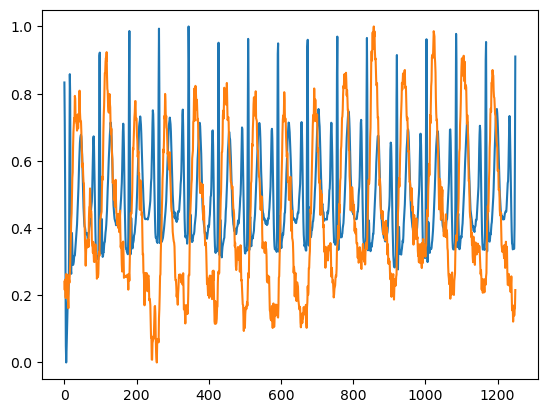

In [7]:
plt.plot(X_df[["ecg"]].iloc[140].values[0])
plt.plot(X_df[["ppg"]].iloc[140].values[0])


In [58]:
NB_TRAIN_SAMPLES = 1000
X_df["i_seg"] = X_df["n_seg"].astype(str) + "_" + X_df.index.astype(str)
X_explode = (
    X_df[["i_seg", "ecg", "ppg"]]
    .iloc[:NB_TRAIN_SAMPLES]
    .explode(["ecg", "ppg"], ignore_index=True)
)
X_explode["step"] = X_explode.index
X_explode = X_explode.fillna(0)
X_explode

/var/folders/vw/2kmjpl310zl2lwgnwpxsyw4r0000gn/T/ipykernel_20707/167340622.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_explode = X_explode.fillna(0)


,i_seg,ecg,ppg,step
0,688_0,0.368867,0.409604,0
1,688_0,0.362063,0.369319,1
2,688_0,0.365301,0.347889,2
3,688_0,0.363867,0.329997,3
4,688_0,0.363760,0.298125,4
...,...,...,...,...
1249995,264_999,0.415670,0.348582,1249995
1249996,264_999,0.442515,0.355926,1249996
1249997,264_999,0.449593,0.359659,1249997
1249998,264_999,0.426747,0.361447,1249998


In [59]:
from tsfresh import extract_features

# extract the features from the ecg
# None of these columns is allowed to contain NaN, Inf or -Inf values.
X_tsfresh = extract_features(
    X_explode, column_id="i_seg", column_sort="step", column_value=None
).reset_index(drop=True)

Feature Extraction: 100%|██████████| 40/40 [10:11<00:00, 15.28s/it]  


In [60]:
X_tsfresh

ecg__variance_larger_than_standard_deviation  ecg__has_duplicate_max  \
0                                             0.0                     0.0   
1                                             0.0                     0.0   
2                                             0.0                     0.0   
3                                             0.0                     0.0   
4                                             0.0                     0.0   
..                                            ...                     ...   
995                                           0.0                     0.0   
996                                           0.0                     0.0   
997                                           0.0                     0.0   
998                                           0.0                     0.0   
999                                           0.0                     0.0   

     ecg__has_duplicate_min  ecg__has_duplicate  ecg__sum_values  \
0                       0.0                 0.0       321.651542   
1                       0.0                 0.0       329.463996   
2                       0.0                 0.0       441.451206   
3                       0.0                 0.0       597.091216   
4                       0.0                 0.0       327.894520   
..                      ...                 ...              ...   
995                     0.0                 0.0       388.617905   
996                     0.0                 0.0       513.296748   
997                     0.0                 0.0       541.239826   
998                     0.0                 0.0       694.996681   
999                     0.0                 0.0       306.281209   

     ecg__abs_energy  ecg__mean_abs_change  ecg__mean_change  \
0         135.844033              0.043108          0.000594   
1         140.618426              0.042657          0.000044   
2         198.304693              0.039928         -0.000051   
3         304.157021              0.032739         -0.000091   
4         139.180142              0.045189          0.000605   
..               ...                   ...               ...   
995       171.771475              0.048886         -0.000148   
996       240.058327              0.034886          0.000059   
997       277.899384              0.040298          0.000193   
998       404.281704              0.035226         -0.000006   
999       110.964134              0.038207          0.000141   

     ecg__mean_second_derivative_central  ecg__median  ecg__mean  ecg__length  \
0                               0.000148     0.173779   0.257321       1250.0   
1                              -0.000029     0.182107   0.263571       1250.0   
2                               0.000011     0.283366   0.353161       1250.0   
3                               0.000022     0.459026   0.477673       1250.0   
4                              -0.000015     0.187701   0.262316       1250.0   
..                                   ...          ...        ...          ...   
995                            -0.000002     0.280452   0.310894       1250.0   
996                            -0.000057     0.418479   0.410637       1250.0   
997                             0.000006     0.427303   0.432992       1250.0   
998                            -0.000002     0.546955   0.555997       1250.0   
999                             0.000028     0.184147   0.245025       1250.0   

     ecg__standard_deviation  ecg__variation_coefficient  ecg__variance  \
0                   0.206061                    0.800792       0.042461   
1                   0.207425                    0.786978       0.043025   
2                   0.184177                    0.521509       0.033921   
3                   0.123102                    0.257712       0.015154   
4                   0.206239                    0.786226       0.042535   
..                       ...                         ...            ...

In [61]:
# Merge back the original df
X_ready = pd.concat([X_df.iloc[:NB_TRAIN_SAMPLES], X_tsfresh], axis=1)
X_ready

n_seg  subject   age gender domain  height  weight   bmi   id  \
0      688  p000750  78.0      M      v   162.0    50.6  19.3  1.0   
1      688  p000750  78.0      M      v   162.0    50.6  19.3  1.0   
2      688  p000750  78.0      M      v   162.0    50.6  19.3  1.0   
3      688  p000750  78.0      M      v   162.0    50.6  19.3  1.0   
4      688  p000750  78.0      M      v   162.0    50.6  19.3  1.0   
..     ...      ...   ...    ...    ...     ...     ...   ...  ...   
995    264  p000427  48.0      M      v   169.0    76.1  26.6  1.0   
996    264  p000427  48.0      M      v   169.0    76.1  26.6  1.0   
997    264  p000427  48.0      M      v   169.0    76.1  26.6  1.0   
998    264  p000427  48.0      M      v   169.0    76.1  26.6  1.0   
999    264  p000427  48.0      M      v   169.0    76.1  26.6  1.0   

                                                   ecg  \
0    [0.3688673837817671, 0.3620627421921535, 0.365...   
1    [0.25735809742643956, 0.23910011930527947, 0.2...   
2    [0.13428866369506492, 0.14334834365416743, 0.1...   
3    [0.17744878960204316, 0.18312116528072353, 0.2...   
4    [0.6703874816047055, 0.5075806829705767, 0.444...   
..                                                 ...   
995  [0.07375290270576584, 0.09428073018130861, 0.1...   
996  [0.318527091238068, 0.3284677391334296, 0.3247...   
997  [0.2739637733740973, 0.2468126223122397, 0.202...   
998  [0.3412645783022509, 0.2331339486808345, 0.157...   
999  [0.18965722125209597, 0.20489338066434948, 0.2...   

                                                   ppg chunk    i_seg  \
0    [0.40960445864963035, 0.36931866813001185, 0.3...   NaN    688_0   
1    [0.36706728559046503, 0.4034043141571599, 0.35...   NaN    688_1   
2    [0.7494333513716098, 0.8147798178151058, 0.799...   NaN    688_2   
3    [0.2668839934294831, 0.26939094339014175, 0.25...   NaN    688_3   
4    [0.27162392568169147, 0.2647447495713346, 0.24...   NaN    688_4   
..                                                 ...   ...      ...   
995  [0.5297296018185839, 0.5996453403303931, 0.631...   NaN  264_995   
996  [0.20367687891992675, 0.20659011084905127, 0.2...   NaN  264_996   
997  [0.1415211004415432, 0.15393001486739444, 0.15...   NaN  264_997   
998  [0.2685799094127722, 0.2797300340643997, 0.293...   NaN  264_998   
999  [0.5271646682642902, 0.5076026448888067, 0.497...   NaN  264_999   

     ecg__variance_larger_than_standard_deviation  ecg__has_duplicate_max  \
0                                             0.0                     0.0   
1                                             0.0                     0.0   
2                                             0.0                     0.0   
3                                             0.0                     0.0   
4                                             0.0                     0.0   
..                                            ...                     ...   
995                                           0.0                     0.0   
996                                           0.0                     0.0   
997                                           0.0                     0.0   
998                                           0.0                     0.0   
999                                           0.0                     0.0   

     ecg__has_duplicate_min  ecg__has_duplicate  ecg__sum_values  \
0                       0.0                 0.0       321.651542   
1                       0.0                 0.0       329.463996   
2                       0.0                 0.0       441.451206   
3                       0.0                 0.0       597.091216   
4                       0.0                 0.0       327.894520   
..                      ...                 ...              ...   
995                     0.0                 0.0       388.617905   
996                     0.0                 0.0       513.296748   
997                     0.0                 0.0      

In [62]:
# Get the columns named
extended_cols = X_tsfresh.columns.to_list()
cat_cols = [
    "gender",
]
num_cols = ["age", "height", "weight", "bmi"]

In [63]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Lasso

clf = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(), cat_cols),
        ("passthrough", extended_cols + num_cols),
    ),
    SimpleImputer(strategy="median"),
    Lasso(alpha=2.0, max_iter=10_000),
)

In [64]:
# Train a regressor on this extracted data
from sklearn.model_selection import cross_validate

cv_results = cross_validate(clf, X_ready, y[:NB_TRAIN_SAMPLES], cv=5)
pd.DataFrame(cv_results)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 783 1566]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 783 1566]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 783 1566]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 783 1566]. At le

,fit_time,score_time,test_score
0,0.404222,0.019185,-1.214076
1,0.344638,0.012279,-0.505668
2,0.234553,0.011814,0.093370
3,0.277745,0.011666,-0.651829
4,0.283477,0.011711,-0.553837


### Select only relevant columns

In [ ]:
from tsfresh import extract_features, extract_relevant_features, select_features

X_filtered = select_features(
    X_tsfresh.dropna(axis=1, how="all"), y[:NB_TRAIN_SAMPLES]
)
X_filtered.head()

,ppg__number_cwt_peaks__n_1,ppg__number_cwt_peaks__n_5,ppg__ar_coefficient__coeff_9__k_10,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.4__ql_0.2","ppg__change_quantiles__f_agg_""var""__isabs_True__qh_0.4__ql_0.2",ppg__ar_coefficient__coeff_8__k_10,ppg__ratio_beyond_r_sigma__r_1,"ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.4__ql_0.2",ppg__quantile__q_0.6,"ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.6__ql_0.2","ppg__change_quantiles__f_agg_""var""__isabs_True__qh_0.4__ql_0.0","ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.6__ql_0.0",ppg__ar_coefficient__coeff_6__k_10,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.4__ql_0.0","ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.4__ql_0.0",ppg__median,ppg__ar_coefficient__coeff_7__k_10,ppg__ar_coefficient__coeff_1__k_10,ecg__ar_coefficient__coeff_9__k_10,ppg__ar_coefficient__coeff_2__k_10,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.0",ppg__ar_coefficient__coeff_3__k_10,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.2",ppg__count_above_mean,ppg__count_below_mean,ppg__ar_coefficient__coeff_4__k_10,ppg__ratio_beyond_r_sigma__r_1.5,ppg__sample_entropy,ecg__number_cwt_peaks__n_1,ppg__skewness,ppg__spkt_welch_density__coeff_8,ppg__ar_coefficient__coeff_10__k_10,ppg__binned_entropy__max_bins_10,ecg__partial_autocorrelation__lag_7,"ppg__fft_coefficient__attr_""real""__coeff_0","ppg__fft_coefficient__attr_""abs""__coeff_0",ppg__mean,ppg__sum_values,"ppg__change_quantiles__f_agg_""var""__isabs_True__qh_0.2__ql_0.0",ppg__ar_coefficient__coeff_0__k_10,ppg__ar_coefficient__coeff_5__k_10,ecg__cid_ce__normalize_True,"ppg__change_quantiles__f_agg_""var""__isabs_True__qh_0.6__ql_0.0",ecg__partial_autocorrelation__lag_1,ecg__autocorrelation__lag_1,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.2__ql_0.0",ecg__large_standard_deviation__r_0.15000000000000002,ppg__quantile__q_0.4,"ppg__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""var""",ppg__quantile__q_0.7,"ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.2__ql_0.0",ecg__ar_coefficient__coeff_1__k_10,ecg__symmetry_looking__r_0.05,ecg__ar_coefficient__coeff_8__k_10,ecg__ar_coefficient__coeff_10__k_10,ecg__permutation_entropy__dimension_3__tau_1,"ppg__change_quantiles__f_agg_""var""__isabs_True__qh_0.6__ql_0.2",ecg__number_peaks__n_3,"ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_0.6__ql_0.4",ecg__ratio_beyond_r_sigma__r_5,ecg__permutation_entropy__dimension_4__tau_1,ecg__permutation_entropy__dimension_5__tau_1,ecg__permutation_entropy__dimension_6__tau_1,ecg__permutation_entropy__dimension_7__tau_1,ppg__lempel_ziv_complexity__bins_10,ecg__autocorrelation__lag_2,ecg__number_peaks__n_1,ppg__symmetry_looking__r_0.05,ppg__lempel_ziv_complexity__bins_100,"ppg__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""var""",ppg__variation_coefficient,"ppg__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.4",ppg__quantile__q_0.3,ppg__fourier_entropy__bins_5,ppg__root_mean_square,ppg__abs_energy,"ppg__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""max""",ecg__ar_coefficient__coeff_0__k_10,"ppg__agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""min""",ppg__friedrich_coefficients__coeff_3__m_3__r_30,ecg__fourier_entropy__bins_100,ppg__friedrich_coefficients__coeff_2__m_3__r_30,ppg__approximate_entropy__m_2__r_0.1,"ppg__agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""mean""","ppg__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""","ppg__agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""min""","ppg__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","ppg__agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""mean""","ecg__fft_aggregated__aggtype_""centroid""","ppg__linear_trend__attr_""intercept""",ecg__friedrich_coefficients__coeff_0__m_3__r_30,ecg__ar_coefficient__coeff_2__k_10,"ppg__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.6",

In [68]:
X_filtered.shape

(1000, 300)

In [71]:
# recreate the df
X_train = pd.concat([X_df.iloc[:NB_TRAIN_SAMPLES], X_filtered], axis=1)
filtered_cols = X_filtered.columns.to_list()
# Create a new pipeline
clf = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(), cat_cols),
        ("passthrough", filtered_cols + num_cols),
    ),
    SimpleImputer(strategy="median"),
    Lasso(alpha=2.0, max_iter=10_000),
)
cv_results = cross_validate(clf, X_train, y[:NB_TRAIN_SAMPLES], cv=5)
pd.DataFrame(cv_results)

,fit_time,score_time,test_score
0,0.046378,0.006849,-0.040143
1,0.039944,0.004027,0.143308
2,0.073117,0.004552,0.418612
3,0.045440,0.003959,0.142576
4,0.023613,0.003828,-0.043745


### Feature selection in a pipeline

In [72]:
X_df["i_seg"] = X_df["n_seg"].astype(str) + "_" + X_df.index.astype(str)
clf = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(), cat_cols),
        ("passthrough", ["i_seg"] + num_cols),
    ),
    SimpleImputer(strategy="median"),
    RelevantFeatureAugmenter(
        column_id="i_seg",
    ),
    Lasso(alpha=2.0, max_iter=10_000),
)


---
## PCA


In [4]:
X_df

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2095,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2785793562708102, 0.28412874583795783, 0.25...","[0.19241192411924118, 0.1603432700993677, 0.13...",val
2096,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.2987085906793936, 0.3161145423919146, 0.212...","[0.11162361623616242, 0.11531365313653143, 0.1...",val
2097,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.20290697674418606, 0.1430232558139535, 0.10...","[0.04311482622085346, 0.04311482622085346, 0.0...",val
2098,470,p090269,76.0,M,m,NaN,NaN,NaN,186.0,"[0.19429778247096094, 0.18373812038014786, 0.1...","[0.20263870094722602, 0.18775372124492556, 0.1...",val


In [5]:
from sklearn.decomposition import PCA

# Assuming lists are in a column named 'list_column'
list_data = np.array(X_df["ecg"].tolist())
pca = PCA(n_components=10)  # Reduce to 10 components
reduced_data = pca.fit_transform(list_data)
reduced_data

array([[ 0.73737056, -0.18782986,  0.69985072, ...,  0.31208046,
        -0.43664478,  0.49667119],
       [ 1.15549245, -0.57799653,  0.45135587, ..., -0.43771401,
        -1.03504805,  0.18882359],
       [-0.50177289, -0.10728163,  0.13878486, ...,  0.27985469,
        -0.10218744,  0.01994156],
       ...,
       [-4.84350892,  0.00634031, -0.03326031, ..., -0.02262965,
        -0.38682187, -0.4594215 ],
       [-3.29710375, -0.01166858, -0.0306845 , ..., -0.25328412,
         0.09525791,  0.40239746],
       [-1.06764319,  0.27357639, -0.05446983, ..., -0.19372831,
        -0.15955819, -0.16297565]])

## Physiocyurve
https://ecgwaves.com/topic/ecg-normal-p-wave-qrs-complex-st-segment-t-wave-j-point/

In [14]:
from physiocurve import ECG

ecg_wrap = ECG(X_df["ecg"].iloc[10], 125)
print(f"{ecg_wrap.argpwave=}")
print(f"{ecg_wrap.argqwave=}")
print(f"{ecg_wrap.argrwave=}")
print(f"{ecg_wrap.argswave=}")
print(f"{ecg_wrap.argtwave=}")
print(f"{ecg_wrap.heartrate=}")

ecg_wrap.argpwave=array([  37,  105,  213,  315,  396,  494,  580,  677,  786,  885,  981,
       1077, 1181])
ecg_wrap.argqwave=array([  52,  106,  201,  336,  409,  491,  787, 1091])
ecg_wrap.argrwave=array([  58,  135,  230,  340,  418,  514,  611,  709,  806,  905, 1002,
       1101, 1198])
ecg_wrap.argswave=array([  63,  148,  242,  345,  431,  527,  624,  722,  819,  918, 1013,
       1114])
ecg_wrap.argtwave=array([  90,  151,  246,  372,  434,  531,  628,  726,  823,  922, 1019,
       1117, 1215])
ecg_wrap.heartrate=array([97.4025974 , 78.94736842, 68.18181818, 96.15384615, 78.125     ,
       77.31958763, 76.53061224, 77.31958763, 75.75757576, 77.31958763,
       75.75757576, 77.31958763])


In [12]:
ecg_ex = X_df["ecg"].iloc[:10].apply(lambda ecg: ECG(ecg, samplerate=125))
ecg_ex

0    <physiocurve.ecg.wrapper.ECG object at 0x1a9d2...
1    <physiocurve.ecg.wrapper.ECG object at 0x168e6...
2    <physiocurve.ecg.wrapper.ECG object at 0x1a90f...
3    <physiocurve.ecg.wrapper.ECG object at 0x1a9d1...
4    <physiocurve.ecg.wrapper.ECG object at 0x1a95e...
5    <physiocurve.ecg.wrapper.ECG object at 0x16861...
6    <physiocurve.ecg.wrapper.ECG object at 0x1a9d2...
7    <physiocurve.ecg.wrapper.ECG object at 0x1a9d2...
8    <physiocurve.ecg.wrapper.ECG object at 0x1a9d2...
9    <physiocurve.ecg.wrapper.ECG object at 0x1a9d2...
Name: ecg, dtype: object

In [21]:
nk.ecg_plot(ecg_ex[0])

ValueError: NeuroKit error: ecg_plot(): The `ecg_signals` argument must be the DataFrame returned by `ecg_process()`.

In [45]:
import neurokit2 as nk

ecg_ex = nk.ecg_process(X_df["ecg"].iloc[1000], sampling_rate=125)
ppg_ex = nk.ppg_process(X_df["ppg"].iloc[1000], sampling_rate=125)

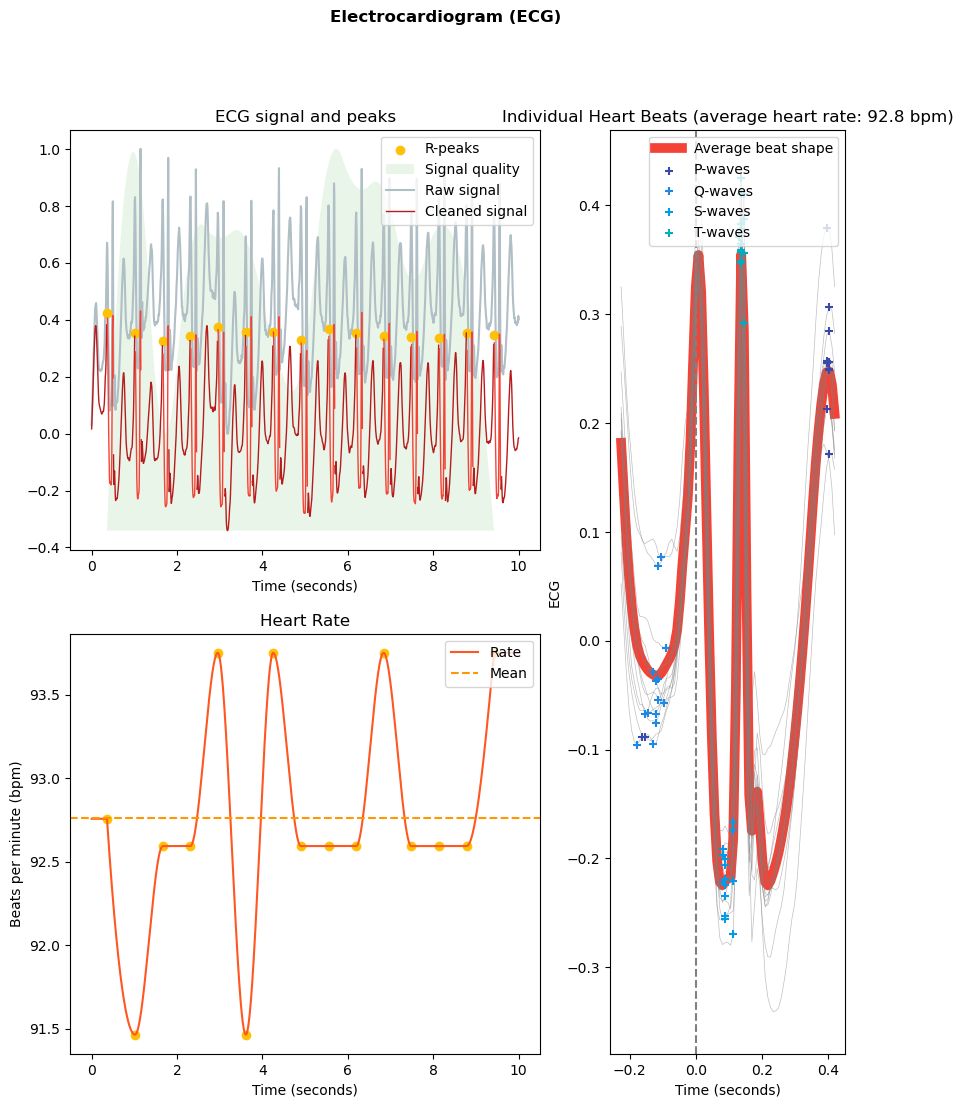

In [35]:
nk.ecg_plot(*ecg_ex)
fig = plt.gcf()
fig.set_size_inches(10, 12, forward=True)

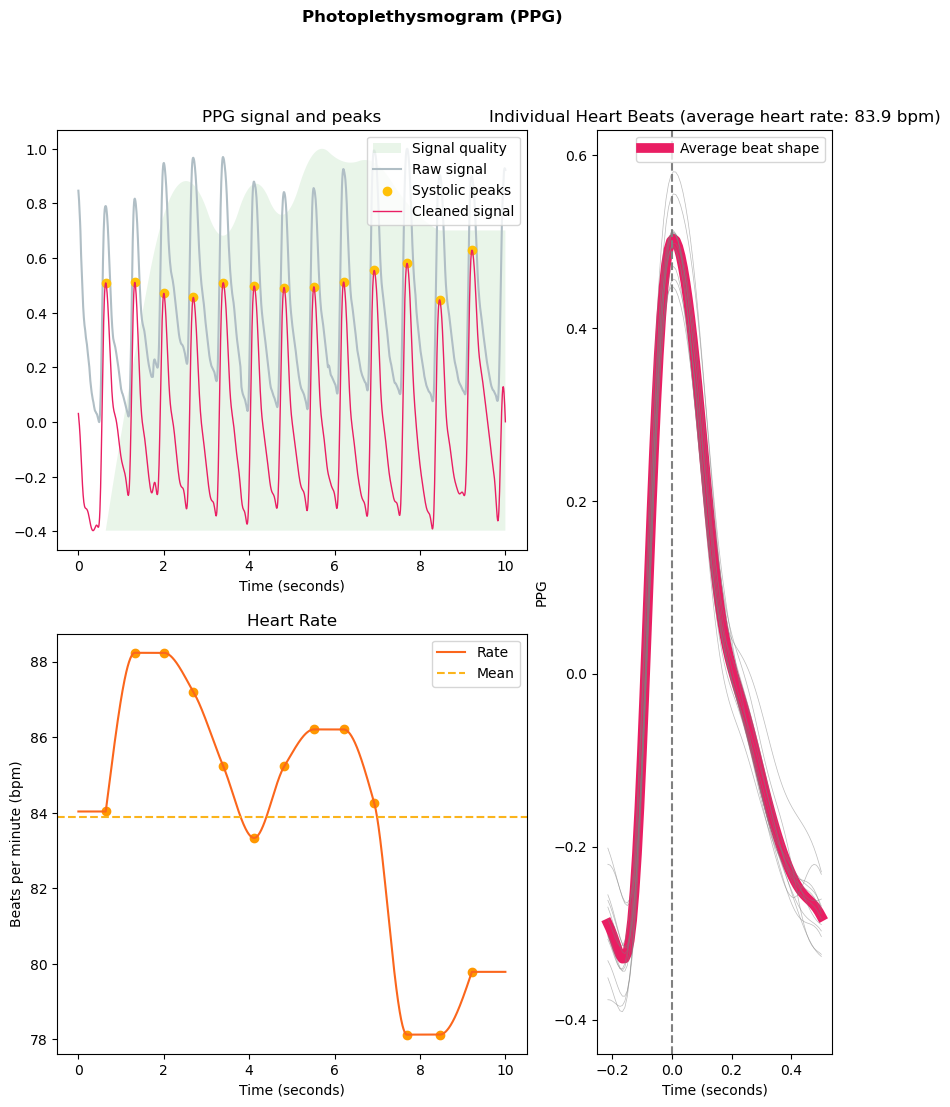

In [36]:
nk.ppg_plot(*ppg_ex)
fig = plt.gcf()
fig.set_size_inches(10, 12, forward=True)

In [46]:
ecg_ex[0]["ECG_Clean"]

0      -0.005543
1       0.294210
2       0.391280
3       0.121249
4      -0.175950
          ...   
1245    0.004275
1246    0.003511
1247    0.000885
1248   -0.002717
1249   -0.001771
Name: ECG_Clean, Length: 1250, dtype: float64

{np.str_('1'):              Signal  Index Label
 -0.251743 -0.042964     56     1
 -0.243662 -0.043321     57     1
 -0.235580 -0.042002     58     1
 -0.227499 -0.043445     59     1
 -0.219417 -0.041169     60     1
 ...             ...    ...   ...
  0.435197 -0.017429    141     1
  0.443279 -0.013789    142     1
  0.451360 -0.009262    143     1
  0.459442 -0.015742    144     1
  0.467524 -0.022311    145     1
 
 [90 rows x 3 columns],
 np.str_('2'):              Signal  Index Label
 -0.251743 -0.017429    141     2
 -0.243662 -0.013789    142     2
 -0.235580 -0.009262    143     2
 -0.227499 -0.015742    144     2
 -0.219417 -0.022311    145     2
 ...             ...    ...   ...
  0.435197 -0.022713    226     2
  0.443279 -0.027010    227     2
  0.451360 -0.024023    228     2
  0.459442 -0.021921    229     2
  0.467524 -0.028870    230     2
 
 [90 rows x 3 columns],
 np.str_('3'):              Signal  Index Label
 -0.251743 -0.027010    227     3
 -0.243662 -0.024023  

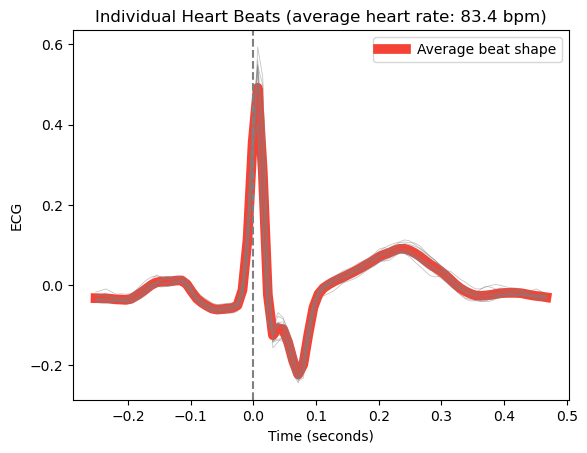

In [47]:
nk.ecg_segment(ecg_ex[0]["ECG_Clean"], sampling_rate=125, show=True)

### Extract features from signal

In [52]:
ecg_signals, rpeaks = ecg_ex

In [54]:
ecg_signals

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,0.341974,-0.005543,83.487941,0.238627,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,0.636364,0.294210,83.487941,0.238627,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,0.948864,0.391280,83.487941,0.238627,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,0.414418,0.121249,83.487941,0.238627,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,0.087358,-0.175950,83.487941,0.238627,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.287287,0.004275,79.787234,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1246,0.279830,0.003511,79.787234,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1247,0.287287,0.000885,79.787234,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1248,0.276278,-0.002717,79.787234,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


In [56]:
# Mean and std of hart rate
print(ecg_signals["ECG_Rate"].mean())
print(ecg_signals["ECG_Rate"].std())

83.41825412663799
3.182746813339392


(      ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  \
 0               0             0              0            0             0   
 1               0             0              0            0             0   
 2               0             0              0            0             0   
 3               0             0              0            0             0   
 4               0             0              0            0             0   
 ...           ...           ...            ...          ...           ...   
 1245            0             0              0            0             0   
 1246            0             0              0            0             0   
 1247            0             0              0            0             0   
 1248            0             0              0            0             0   
 1249            0             0              0            0             0   
 
       ECG_R_Offsets  ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  

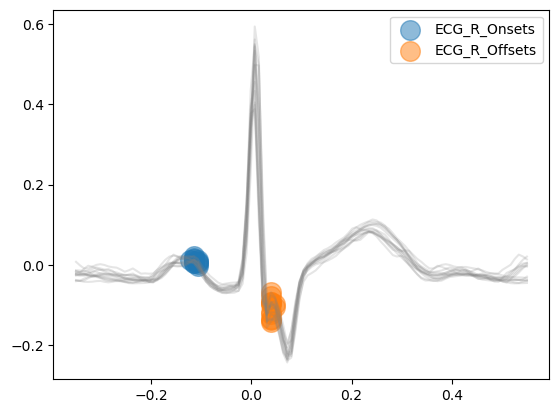

In [62]:
nk.ecg_delineate(
    ecg_signals, rpeaks, sampling_rate=125, show=True, show_type="bounds_R"
)

In [53]:
rpeaks

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([  88,  173,  259,  346,  436,  523,  611,  698,  787,  882,  977,
        1072, 1166]),
 'ECG_R_Peaks_Uncorrected': array([  88,  173,  259,  346,  436,  523,  611,  698,  787,  882,  977,
        1072, 1166]),
 'ECG_fixpeaks_ectopic': [],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([0.71866667, 0.68      , 0.688     , 0.696     , 0.72      ,
        0.696     , 0.704     , 0.696     , 0.712     , 0.76      ,
        0.76      , 0.76      , 0.752     ]),
 'ECG_fixpeaks_drrs': array([ 0.0667735 , -0.92948718,  0.19230769,  0.19230769,  0.57692308,
        -0.57692308,  0.19230769, -0.19230769,  0.38461538,  1.15384615,
         0.        ,  0.        , -0.19230769]),
 'ECG_fixpeaks_mrrs': array([ 0.43589744, -0.61538462, -0.30769231,  0.        ,  0.38461538,
        -0.30769231,  0.        , -0.61538462, -0

In [64]:
# Use this
nk.ecg_intervalrelated(ecg_signals, sampling_rate=125)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,83.418254,[[718.6666666666666]],[[30.85842549843436]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[19.145376845219175]],[[18.86988943456552]],[[0.0429384399328864]],[[0.026640134756798484]],[[708.0]],[[23.7216]],[[0.03350508474576271]],[[58.0]],[[1.6117951476175865]],[[696.0]],[[758.4]],[[0.0]],[[25.0]],[[680.0]],[[760.0]],[[4.0]],[[15.625]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[0.0]],[[nan]],[[nan]],[[nan]],[[nan]],[[13.343026779421663]],[[40.405220184795695]],[[0.33023027020757545]],[[1693.7203597970176]],[[3.028189994125681]],[[3.9358118180685477]],[[489.41873389617336]],[[0.5]],[[0.6666666666666666]],[[0.8333333333333334]],[[0.3333333333333333]],[[73.68421052631578]],[[73.67990616028519]],[[73.68901200861383]],[[33.33333333333333]],[[0.8253968253968254]],[[0.17460317460317462]],[[12.899612397277677]],[[5.93295878967653]],[[0.5662379317047881]],[[0.4337620682952119]],[[30.404436387904234]],[[26.611126735177958]],[[0.5947228029702252]],[[0.4052771970297746]],[[23.35411903782837]],[[19.27890124093828]],[[1.159130683536167]],[[1.4255642360081722]],[[1.4359256000836313]],[[1.435400222354864]],[[-0.06563875329612401]],[[0.002473455317201445]],[[-0.5003685402000814]],[[0.00033638612205000355]],[[0.11375662262811666]],[[0.030716580297483365]],[[inf]],[[2.792481250360578]],[[1.2328272571499108]],[[nan]],[[nan]],[[nan]],[[1.2895469757520996]],[[nan]],[[1.3655118216807183]],[[1.4937343753004815]]


In [66]:
nk.hrv(rpeaks, sampling_rate=125)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,718.666667,30.858425,NaN,NaN,NaN,NaN,NaN,NaN,19.145377,18.869889,0.042938,0.02664,708.0,23.7216,0.033505,58.0,1.611795,696.0,758.4,0.0,25.0,680.0,760.0,4.0,15.625,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,13.343027,40.40522,0.33023,1693.72036,3.02819,3.935812,489.418734,0.5,0.666667,0.833333,0.333333,73.684211,73.679906,73.689012,33.333333,0.825397,0.174603,12.899612,5.932959,0.566238,0.433762,30.404436,26.611127,0.594723,0.405277,23.354119,19.278901,1.159131,1.425564,1.435926,1.4354,-0.065639,0.002473,-0.500369,0.000336,0.113757,0.030717,inf,2.792481,1.232827,NaN,NaN,NaN,1.289547,NaN,1.365512,1.493734


In [67]:
nk.hrv_time(rpeaks, sampling_rate=125)

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,718.666667,30.858425,NaN,NaN,NaN,NaN,NaN,NaN,19.145377,18.869889,0.042938,0.02664,708.0,23.7216,0.033505,58.0,1.611795,696.0,758.4,0.0,25.0,680.0,760.0,4.0,15.625


In [68]:
nk.hrv_frequency(rpeaks, sampling_rate=125)

,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF
0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [69]:
nk.hrv_nonlinear(rpeaks, sampling_rate=125)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,13.343027,40.40522,0.33023,1693.72036,3.02819,3.935812,489.418734,0.5,0.666667,0.833333,0.333333,73.684211,73.679906,73.689012,33.333333,0.825397,0.174603,12.899612,5.932959,0.566238,0.433762,30.404436,26.611127,0.594723,0.405277,23.354119,19.278901,1.159131,1.425564,1.435926,1.4354,-0.065639,0.002473,-0.500369,0.000336,0.113757,0.030717,inf,2.792481,1.232827,NaN,NaN,NaN,1.289547,NaN,1.365512,1.493734


In [72]:
nk.hrv_rqa(rpeaks, sampling_rate=125)

,RecurrenceRate,DiagRec,Determinism,DeteRec,L,Divergence,LEn,Laminarity,LamiDet,TrappingTime,VMax,VEn,W,WMax,WEn
0,0.0,NaN,NaN,NaN,0,NaN,0.0,NaN,NaN,0,0,0.0,3.5,5,1.386294


In [73]:
sub_X = pd.concat([X_df.iloc[100:200], X_df.iloc[-200:-100]])
sub_X

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
100,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.030743477984207172, 0.061255836701360235, 0...","[0.7821912198018665, 0.8189236801418973, 0.842...",NaN
101,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.12071713495323859, 0.14047159586599356, 0.1...","[0.7254595324031047, 0.7855750035189372, 0.766...",NaN
102,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.5950829165388151, 0.5862419059595467, 0.569...","[0.10301103802016062, 0.09784221935552694, 0.1...",NaN
103,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17003136184351897, 0.10628002896801854, 0.0...","[0.37535904334898795, 0.43587283825502365, 0.4...",NaN
104,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6244177000379149, 0.6237687119225601, 0.623...","[0.32447838307875937, 0.34032693316012347, 0.3...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2582,p025225,32.0,F,m,NaN,NaN,NaN,2.0,"[0.5277368679430535, 0.5429553264604811, 0.527...","[0.8159817351598173, 0.8589041095890412, 0.889...",NaN
1996,2582,p025225,32.0,F,m,NaN,NaN,NaN,2.0,"[0.514367816091954, 0.5340038314176245, 0.5536...","[0.31778290993071595, 0.3196304849884527, 0.31...",NaN
1997,2582,p025225,32.0,F,m,NaN,NaN,NaN,2.0,"[0.33526927138331575, 0.3405491024287223, 0.34...","[0.3029958285930982, 0.2684869169510808, 0.237...",NaN
1998,2582,p025225,32.0,F,m,NaN,NaN,NaN,2.0,"[0.5840182648401827, 0.5981735159817352, 0.607...","[0.25532900834105654, 0.23076923076923078, 0.2...",NaN


In [99]:
process_ecg_df = sub_X["ecg"].apply(
    lambda ecg: nk.ecg_process(ecg, sampling_rate=125)[0]
)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/s

In [102]:
process_ecg_df.iloc[0]

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,0.030743,0.016482,92.756184,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,0.061256,0.045611,92.756184,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,0.105587,0.080649,92.756184,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,0.145950,0.115870,92.756184,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,0.181203,0.150928,92.756184,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.393774,-0.044385,93.750000,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1246,0.388975,-0.039085,93.750000,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1247,0.390802,-0.029653,93.750000,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1248,0.412886,-0.016579,93.750000,0.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


In [110]:
nk.ecg_intervalrelated(process_ecg_df.iloc[10], sampling_rate=125)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,96.275146,[[622.0]],[[121.37994442695593]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[209.9350548925245]],[[219.06777697573622]],[[0.19514460518803203]],[[0.33751616542206514]],[[644.0]],[[166.0512]],[[0.25784347826086956]],[[238.0]],[[0.5781785442602521]],[[496.0]],[[747.2]],[[75.0]],[[75.0]],[[408.0]],[[760.0]],[[4.0]],[[85.9375]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[0.0]],[[nan]],[[nan]],[[nan]],[[nan]],[[154.9043106390053]],[[73.89033643299928]],[[2.0964082465569254]],[[35958.45471613503]],[[0.4770063281531011]],[[5.262771129989737]],[[140.98463227160917]],[[0.8333333333333334]],[[1.0]],[[1.0]],[[1.0]],[[55.82329317269076]],[[55.4152020878462]],[[56.18330030620593]],[[50.0]],[[0.6340594059405941]],[[0.3659405940594059]],[[123.9741908624533]],[[94.1828009776732]],[[0.1333919437340154]],[[0.8666080562659844]],[[26.986865492140975]],[[68.78583363666466]],[[0.5420205107108225]],[[0.4579794892891775]],[[89.71591528009651]],[[82.4678449733316]],[[0.25683527612760654]],[[0.553385167858915]],[[0.3378967145394933]],[[0.3492940784835089]],[[0.4629039620064219]],[[-0.049769879739847145]],[[-0.47940428365994564]],[[1.1364706617866856e-05]],[[0.013170845872908225]],[[0.20431135346879614]],[[inf]],[[2.855388542207534]],[[1.7700285510968112]],[[nan]],[[nan]],[[nan]],[[0.5594210599468065]],[[nan]],[[6.3613096391322985]],[[1.1949875002403854]]


In [105]:
hrv_cols = [
    "ECG_Rate_Mean",
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_SDANN1",
    "HRV_SDNNI1",
    "HRV_SDANN2",
    "HRV_SDNNI2",
    "HRV_SDANN5",
    "HRV_SDNNI5",
    "HRV_RMSSD",
    "HRV_SDSD",
    "HRV_CVNN",
    "HRV_CVSD",
    "HRV_MedianNN",
    "HRV_MadNN",
    "HRV_MCVNN",
    "HRV_IQRNN",
    "HRV_SDRMSSD",
    "HRV_Prc20NN",
    "HRV_Prc80NN",
    "HRV_pNN50",
    "HRV_pNN20",
    "HRV_MinNN",
    "HRV_MaxNN",
    "HRV_HTI",
    "HRV_TINN",
    "HRV_ULF",
    "HRV_VLF",
    "HRV_LF",
    "HRV_HF",
    "HRV_VHF",
    "HRV_TP",
    "HRV_LFHF",
    "HRV_LFn",
    "HRV_HFn",
    "HRV_LnHF",
    "HRV_SD1",
    "HRV_SD2",
    "HRV_SD1SD2",
    "HRV_S",
    "HRV_CSI",
    "HRV_CVI",
    "HRV_CSI_Modified",
    "HRV_PIP",
    "HRV_IALS",
    "HRV_PSS",
    "HRV_PAS",
    "HRV_GI",
    "HRV_SI",
    "HRV_AI",
    "HRV_PI",
    "HRV_C1d",
    "HRV_C1a",
    "HRV_SD1d",
    "HRV_SD1a",
    "HRV_C2d",
    "HRV_C2a",
    "HRV_SD2d",
    "HRV_SD2a",
    "HRV_Cd",
    "HRV_Ca",
    "HRV_SDNNd",
    "HRV_SDNNa",
    "HRV_DFA_alpha1",
    "HRV_MFDFA_alpha1_Width",
    "HRV_MFDFA_alpha1_Peak",
    "HRV_MFDFA_alpha1_Mean",
    "HRV_MFDFA_alpha1_Max",
    "HRV_MFDFA_alpha1_Delta",
    "HRV_MFDFA_alpha1_Asymmetry",
    "HRV_MFDFA_alpha1_Fluctuation",
    "HRV_MFDFA_alpha1_Increment",
    "HRV_ApEn",
    "HRV_SampEn",
    "HRV_ShanEn",
    "HRV_FuzzyEn",
    "HRV_MSEn",
    "HRV_CMSEn",
    "HRV_RCMSEn",
    "HRV_CD",
    "HRV_HFD",
    "HRV_KFD",
    "HRV_LZC",
]

In [109]:
# Apply ecg_intervalrelated function to the processed ECG data
intervalrelated_features = sub_X["ecg"].apply(
    lambda ecg: nk.ecg_intervalrelated(
        nk.ecg_process(ecg, sampling_rate=125)[0], sampling_rate=125
    )
)

# Concatenate the resulting dataframe to the initial one
intervalrelated_df = pd.concat(intervalrelated_features.tolist(), axis=1).T
sub_X_with_features = pd.concat(
    [sub_X.reset_index(drop=True), intervalrelated_df.reset_index(drop=True)],
    axis=1,
)
sub_X_with_features

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

ValueError: NeuroKit error: the window cannot contain more data points than the time series. Decrease 'scale'.

In [119]:
# Process the SCG signal
SAMPLING_RATE = 125
process_ecg = sub_X["ecg"].apply(
    lambda ecg: nk.ecg_process(ecg, sampling_rate=SAMPLING_RATE)
)
print(f"{process_ecg.shape=}")
summary_ecg = process_ecg.apply(
    lambda ecg: nk.ecg_intervalrelated(ecg[0], sampling_rate=SAMPLING_RATE)
)
print(f"{summary_ecg.shape=}")

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/signal/s

process_ecg.shape=(200,)


/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

ValueError: NeuroKit error: the window cannot contain more data points than the time series. Decrease 'scale'.

In [118]:
nk.ecg_intervalrelated(process_ecg.iloc[0][0], sampling_rate=SAMPLING_RATE)

/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,HRV_PAS,HRV_GI,HRV_SI,HRV_AI,HRV_PI,HRV_C1d,HRV_C1a,HRV_SD1d,HRV_SD1a,HRV_C2d,HRV_C2a,HRV_SD2d,HRV_SD2a,HRV_Cd,HRV_Ca,HRV_SDNNd,HRV_SDNNa,HRV_DFA_alpha1,HRV_MFDFA_alpha1_Width,HRV_MFDFA_alpha1_Peak,HRV_MFDFA_alpha1_Mean,HRV_MFDFA_alpha1_Max,HRV_MFDFA_alpha1_Delta,HRV_MFDFA_alpha1_Asymmetry,HRV_MFDFA_alpha1_Fluctuation,HRV_MFDFA_alpha1_Increment,HRV_ApEn,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,92.760532,[[646.8571428571429]],[[5.303948353054367]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[8.301992346604333]],[[8.545504141104903]],[[0.008199566800216556]],[[0.01283435212593426]],[[648.0]],[[0.0]],[[0.0]],[[6.0]],[[0.6388765649999399]],[[640.0]],[[648.0]],[[0.0]],[[0.0]],[[640.0]],[[656.0]],[[1.75]],[[0.0]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[0.0]],[[nan]],[[nan]],[[nan]],[[nan]],[[6.042583926832998]],[[3.566223312966892]],[[1.6943930305379327]],[[67.69881994173582]],[[0.5901818420974748]],[[2.53755120852494]],[[8.418880976711039]],[[0.7142857142857143]],[[1.0]],[[1.0]],[[0.3333333333333333]],[[40.0]],[[40.02432660749149]],[[39.97555509515208]],[[62.5]],[[0.4285714285714285]],[[0.5714285714285715]],[[3.9999999999999996]],[[4.618802153517006]],[[0.2704714640198512]],[[0.7295285359801487]],[[1.8546811610282181]],[[3.045998442034358]],[[0.38839848675914257]],[[0.6116015132408577]],[[3.1176788007324436]],[[3.912252538002184]],[[0.028458886423850496]],[[0.3783888025386408]],[[0.07835162030780968]],[[0.029691448082234895]],[[0.739701103645156]],[[0.27029586106471903]],[[-0.6285983409104862]],[[2.5512677664347433e-06]],[[0.005545250024359275]],[[0.3934336822262283]],[[0.8754687373539001]],[[1.3787834934861756]],[[1.0489726695353387]],[[nan]],[[nan]],[[nan]],[[7.403462725442179e-17]],[[nan]],[[2.6843732440984915]],[[1.0878156920164583]]


In [129]:
for i, ecg in enumerate(process_ecg.iloc[6:]):
    print(i)
    nk.hrv(ecg[0], sampling_rate=SAMPLING_RATE)

0
1


/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/Users/tristanwaddington/anaconda3/envs/MAP2/lib/python3.12/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: invalid valu

ValueError: NeuroKit error: the window cannot contain more data points than the time series. Decrease 'scale'.

In [137]:
process_ecg.iloc[3][1]

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([  61,  145,  228,  312,  396,  479,  562,  645,  729,  812,  896,
         979, 1062, 1154, 1245]),
 'ECG_R_Peaks_Uncorrected': array([  61,  145,  228,  312,  396,  479,  563,  646,  729,  813,  896,
         979, 1063, 1146, 1245]),
 'ECG_fixpeaks_ectopic': [],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([0.67657143, 0.672     , 0.664     , 0.672     , 0.672     ,
        0.664     , 0.664     , 0.664     , 0.672     , 0.664     ,
        0.672     , 0.664     , 0.664     , 0.736     , 0.728     ]),
 'ECG_fixpeaks_drrs': array([ 0.22924096, -0.28527764, -0.49923586,  0.49923586,  0.        ,
        -0.49923586,  0.        ,  0.        ,  0.49923586, -0.49923586,
         0.49923586, -0.49923586,  0.        ,  4.49312277, -0.49923586]),
 'ECG_fixpeaks_mrrs': array([ 0.21978022,  0.        , -0.38461538,  

In [152]:
epochs = nk.epochs_create(
    process_ecg.iloc[30][0]["ECG_Clean"].values,
    events=process_ecg.iloc[30][1]["ECG_R_Peaks"],
    sampling_rate=SAMPLING_RATE,
)

In [153]:
epochs

{np.str_('1'):             Signal  Index Label
 0.000000  0.363819     51     1
 0.008084  0.308831     52     1
 0.016168  0.128623     53     1
 0.024253 -0.006239     54     1
 0.032337 -0.027858     55     1
 ...            ...    ...   ...
 0.735663 -0.105803    142     1
 0.743747 -0.101564    143     1
 0.751832 -0.079347    144     1
 0.759916 -0.003366    145     1
 0.768000  0.157156    146     1
 
 [96 rows x 3 columns],
 np.str_('2'):             Signal  Index Label
 0.000000  0.313692    147     2
 0.008083  0.306321    148     2
 0.016167  0.138567    149     2
 0.024250 -0.019087    150     2
 0.032333 -0.061451    151     2
 ...            ...    ...   ...
 0.743667 -0.096104    239     2
 0.751750 -0.087157    240     2
 0.759833 -0.038377    241     2
 0.767917  0.092090    242     2
 0.776000  0.270018    243     2
 
 [97 rows x 3 columns],
 np.str_('3'):             Signal  Index Label
 0.000000  0.343433    244     3
 0.008083  0.221878    245     3
 0.016167  0.03

In [154]:
data = nk.epochs_to_df(epochs)
data

,Signal,Index,Label,Time
0,0.363819,51,1,0.000000
1,0.308831,52,1,0.008084
2,0.128623,53,1,0.016168
3,-0.006239,54,1,0.024253
4,-0.027858,55,1,0.032337
...,...,...,...,...
2407,0.000000,2458,13,9.959974
2408,0.000000,2459,13,9.967981
2409,0.000000,2460,13,9.975987
2410,0.000000,2461,13,9.983994


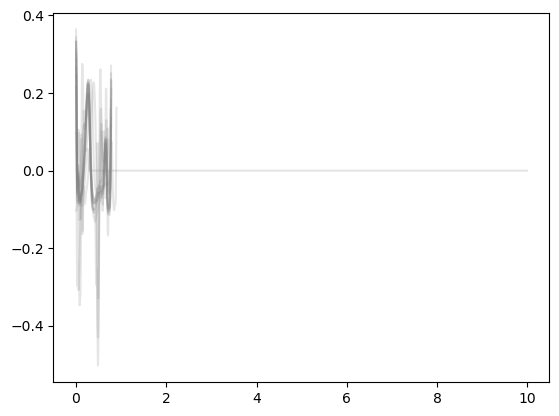

In [155]:
fig, ax = plt.subplots()
data.Label = data.Label.astype(int)
for label in data.Label.unique():
    epoch_data = data[data.Label == label]
    ax.plot(epoch_data.Time, epoch_data.Signal, color="grey", alpha=0.2)

In [141]:
nk.ecg_delineate(
    process_ecg.iloc[3][0]["ECG_Clean"].values, sampling_rate=SAMPLING_RATE
)

(      ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  \
 0               0             0              0            0             0   
 1               0             0              0            0             0   
 2               0             0              0            0             0   
 3               0             0              0            0             0   
 4               0             0              0            0             0   
 ...           ...           ...            ...          ...           ...   
 1245            0             0              0            0             0   
 1246            0             0              0            0             0   
 1247            0             0              0            0             0   
 1248            0             0              0            0             0   
 1249            0             0              0            0             0   
 
       ECG_R_Offsets  ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  

In [ ]:
# From https://github.com/neuropsychology/NeuroKit/blob/master/neurokit2/ecg/ecg_delineate.py
def _ecg_delineate_plot(
    ecg_signal,
    rpeaks=None,
    signals=None,
    signal_features_type="all",
    sampling_rate=1000,
    window_start=-0.35,
    window_end=0.55,
):
    """
    import neurokit2 as nk
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    ecg_signal = nk.data("ecg_100hz")

    # Extract R-peaks locations
     _, rpeaks = nk.ecg_peaks(ecg_signal, sampling_rate=1000)

    # Delineate the ECG signal with ecg_delineate()
    signals, waves = nk.ecg_delineate(ecg_signal, rpeaks, sampling_rate=1000)

    # Plot the ECG signal with markings on ECG peaks
    _ecg_delineate_plot(ecg_signal, rpeaks=rpeaks, signals=signals,
                        signal_features_type='peaks', sampling_rate=1000)

    # Plot the ECG signal with markings on boundaries of R peaks
    _ecg_delineate_plot(ecg_signal, rpeaks=rpeaks, signals=signals,
                        signal_features_type='bound_R', sampling_rate=1000)

    # Plot the ECG signal with markings on boundaries of P peaks
    _ecg_delineate_plot(ecg_signal, rpeaks=rpeaks, signals=signals,
                        signal_features_type='bound_P', sampling_rate=1000)

    # Plot the ECG signal with markings on boundaries of T peaks
    _ecg_delineate_plot(ecg_signal, rpeaks=rpeaks, signals=signals,
                        signal_features_type='bound_T', sampling_rate=1000)

    # Plot the ECG signal with markings on all peaks and boundaries
    _ecg_delineate_plot(ecg_signal, rpeaks=rpeaks, signals=signals,
                        signal_features_type='all', sampling_rate=1000)

    """

    data = pd.DataFrame({"Signal": list(ecg_signal)})
    data = pd.concat([data, signals], axis=1)

    # Try retrieving right column
    if isinstance(rpeaks, dict):
        rpeaks = rpeaks["ECG_R_Peaks"]
    # Segment the signal around the R-peaks
    epochs = epochs_create(
        data,
        events=rpeaks,
        sampling_rate=sampling_rate,
        epochs_start=window_start,
        epochs_end=window_end,
    )
    data = epochs_to_df(epochs)
    data_cols = data.columns.values

    dfs = []
    for feature in data_cols:
        if signal_features_type == "peaks":
            if any(x in str(feature) for x in ["Peak"]):
                df = data[feature]
                dfs.append(df)
        elif signal_features_type == "bounds_R":
            if any(
                x in str(feature) for x in ["ECG_R_Onsets", "ECG_R_Offsets"]
            ):
                df = data[feature]
                dfs.append(df)
        elif signal_features_type == "bounds_T":
            if any(
                x in str(feature) for x in ["ECG_T_Onsets", "ECG_T_Offsets"]
            ):
                df = data[feature]
                dfs.append(df)
        elif signal_features_type == "bounds_P":
            if any(
                x in str(feature) for x in ["ECG_P_Onsets", "ECG_P_Offsets"]
            ):
                df = data[feature]
                dfs.append(df)
        elif signal_features_type == "all":
            if any(x in str(feature) for x in ["Peak", "Onset", "Offset"]):
                df = data[feature]
                dfs.append(df)
    features = pd.concat(dfs, axis=1)

    fig, ax = plt.subplots()
    data.Label = data.Label.astype(int)
    for label in data.Label.unique():
        epoch_data = data[data.Label == label]
        ax.plot(epoch_data.Time, epoch_data.Signal, color="grey", alpha=0.2)
    for i, feature_type in enumerate(features.columns.values):  # pylint: disable=W0612
        event_data = data[data[feature_type] == 1.0]
        ax.scatter(
            event_data.Time,
            event_data.Signal,
            label=feature_type,
            alpha=0.5,
            s=200,
        )
        ax.legend()
    return fig


---
## Sandbox original code - do not touch

In [ ]:
# original estimator.py
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder


class IgnoreDomain(RandomForestRegressor):
    def fit(self, X, y):
        # Ignore the samples with missing target
        X = X[y != -1]
        y = y[y != -1]
        return super().fit(X, y)


def get_estimator():
    return make_pipeline(
        make_column_transformer(
            ("passthrough", ["age"]),
            (
                OrdinalEncoder(
                    handle_unknown="use_encoded_value", unknown_value=-1
                ),
                ["gender"],
            ),
        ),
        IgnoreDomain(n_estimators=50),
    )
